# 📈 Exploratory Data Analysis: Telco Customer Churn

This notebook explores the Telco Customer Churn dataset to identify patterns and factors that contribute to customer churn. The insights will help refine our machine learning models and business strategies.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from data_preprocessing import load_and_clean_data

# Set visual aesthetics
plt.style.use('ggplot')
sns.set_palette("viridis")
%matplotlib inline

# File Path
file_path = 'data/WA_Fn-UseC_-Telco-Customer-Churn.csv'

## 1. Data Loading and Initial Inspection

In [2]:
# Using the existing load_and_clean_data function but also getting a raw version for reference
df_raw = pd.read_csv(file_path)
df = load_and_clean_data(file_path)

print("Raw Data Preview:")
display(df_raw.head())
print("\nDataset Information:")
display(df.info())
print("\nSummary Statistics:")
display(df.describe())

Dataset shape: (7043, 21)
Raw Data Preview:


/Users/shyamverma/Documents/GenAI_Project_Capstone/data_preprocessing.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(median_tc, inplace=True)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   gender             7043 non-null   object  
 1   SeniorCitizen      7043 non-null   object  
 2   Partner            7043 non-null   int64   
 3   Dependents         7043 non-null   int64   
 4   tenure             7043 non-null   int64   
 5   PhoneService       7043 non-null   int64   
 6   MultipleLines      6361 non-null   float64 
 7   InternetService    7043 non-null   object  
 8   OnlineSecurity     7043 non-null   int64   
 9   OnlineBackup       7043 non-null   int64   
 10  DeviceProtection   7043 non-null   int64   
 11  TechSupport        7043 non-null   int64   
 12  StreamingTV        7043 non-null   int64   
 13  StreamingMovies    7043 non-null   int64   
 14  Contract           7043 non-null   object  
 15  PaperlessBilling   7043 non-null 

None


Summary Statistics:


,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,AvgChargePerMonth
count,7043.000000,7043.000000,7043.000000,7043.000000,6361.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.483033,0.299588,32.371149,0.903166,0.467065,0.286668,0.344881,0.343888,0.290217,0.384353,0.387903,0.592219,64.761692,2281.916928,0.265370,61.173413
std,0.499748,0.458110,24.559481,0.295752,0.498953,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307,0.491457,30.090047,2265.270398,0.441561,61.019723
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.000000,9.183333
25%,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.500000,402.225000,0.000000,26.274411
50%,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,1397.475000,0.000000,61.150000
75%,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.850000,3786.600000,1.000000,84.940047
max,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,1.000000,1397.475000


## 2. Target Variable Analysis: Churn Distribution

Churn Distribution:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


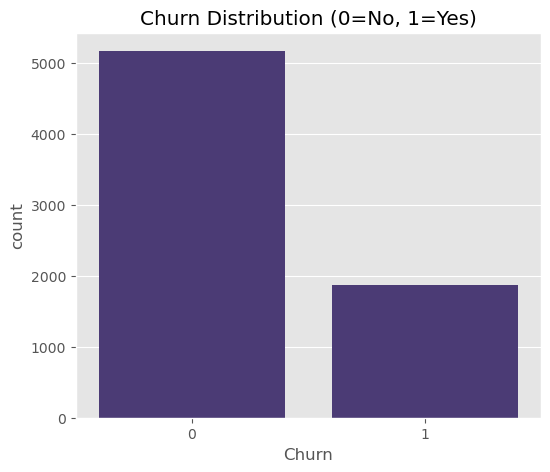

In [3]:
churn_counts = df['Churn'].value_counts(normalize=True).round(4) * 100
print(f"Churn Distribution:\n{churn_counts}")

plt.figure(figsize=(6, 5))
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution (0=No, 1=Yes)')
plt.show()

## 3. Demographics and Churn

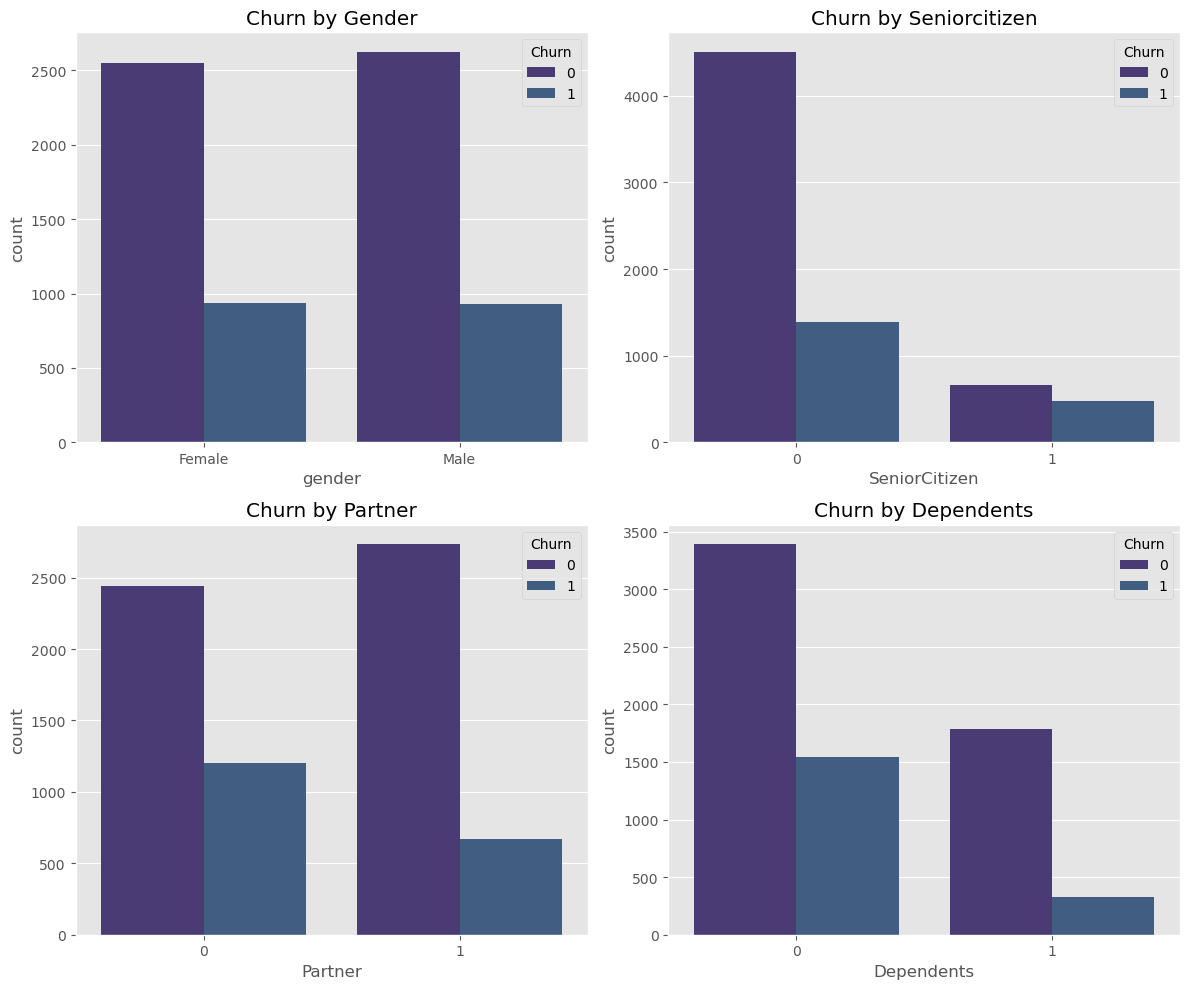

In [4]:
demographics = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, feature in enumerate(demographics):
    row, col = divmod(i, 2)
    sns.countplot(x=feature, hue='Churn', data=df, ax=axes[row, col])
    axes[row, col].set_title(f'Churn by {feature.capitalize()}')

plt.tight_layout()
plt.show()

## 4. Contract and Monthly Charges

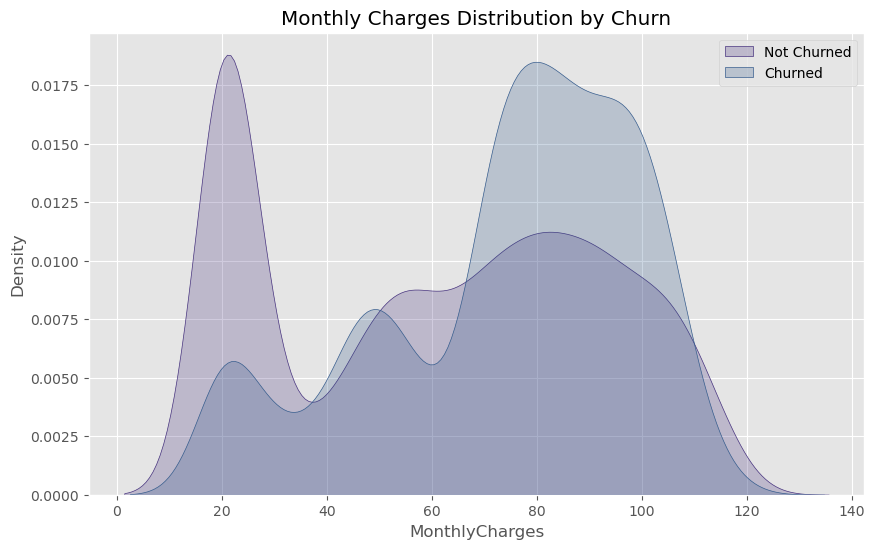

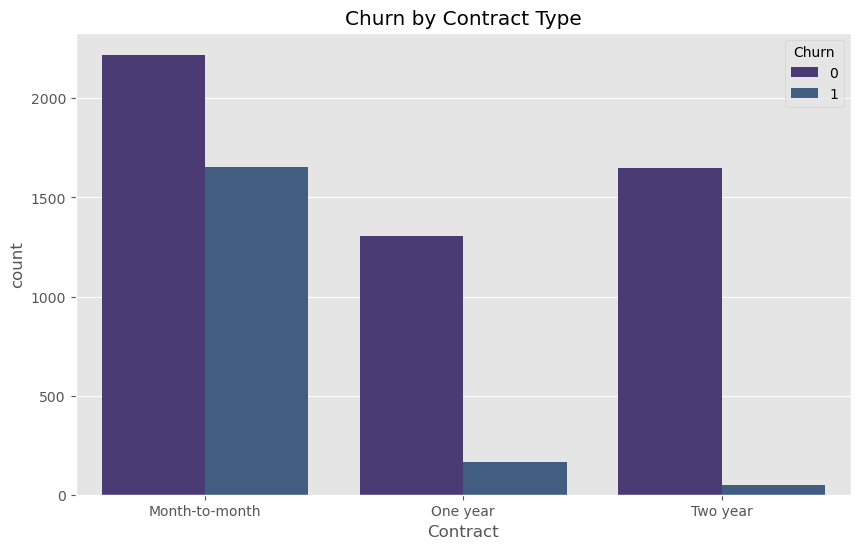

In [5]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['Churn'] == 0]['MonthlyCharges'], label='Not Churned', fill=True)
sns.kdeplot(df[df['Churn'] == 1]['MonthlyCharges'], label='Churned', fill=True)
plt.title('Monthly Charges Distribution by Churn')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.show()

## 5. Internet Service and Tech Support

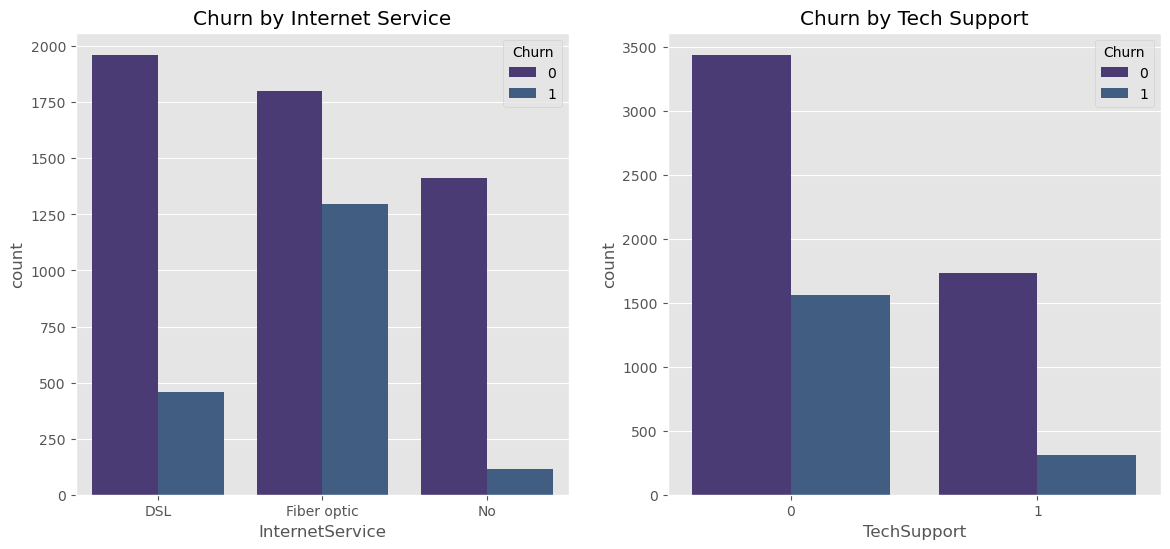

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(x='InternetService', hue='Churn', data=df, ax=axes[0])
axes[0].set_title('Churn by Internet Service')

sns.countplot(x='TechSupport', hue='Churn', data=df, ax=axes[1])
axes[1].set_title('Churn by Tech Support')

plt.show()

## 6. Correlation Analysis

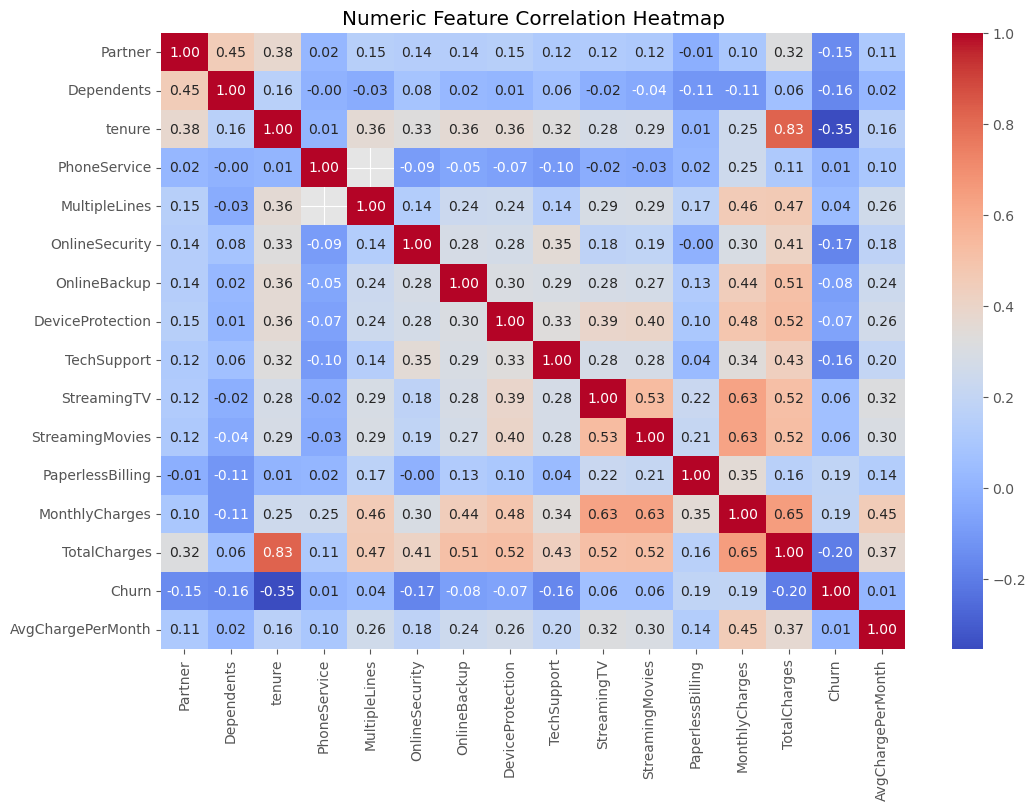

In [7]:
# Focus on numeric correlations
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Numeric Feature Correlation Heatmap')
plt.show()

## 7. Tenure Analysis

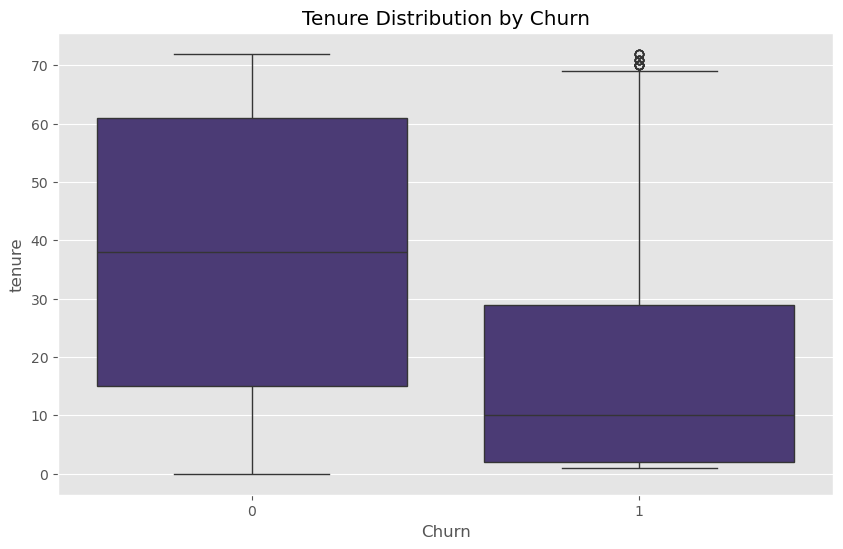

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure Distribution by Churn')
plt.show()

## 🔎 Summary of Findings

1. **Contract Type**: Month-to-month contracts have a significantly higher churn rate compared to one or two-year contracts.
2. **Tenure**: New customers (low tenure) are much more likely to churn.
3. **Charges**: Customers with higher monthly charges tend to churn more, especially in the $70-$110 range.
4. **Services**: Fiber optic internet users and those without tech support/online security have higher churn risk.
5. **Demographics**: Senior citizens show higher churn rates.